# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> Data Science 2: Advanced Topics in Data Science

## Homework 1: Artificial Neural Networks and Regularization


**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas & Kevin Rader

<hr style="height:2pt">

In [1]:
import random, os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

# These optional libraries will be installed on Open OnDemand soon
#import torchvision
#from torchvision import transforms

random.seed(109)
np.random.seed(109)
torch.manual_seed(109);

In [2]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [3]:
# measure notebook runtime
time_start = time.time()

<div style = "background: lightsalmon; border: thin solid black; border-radius: 2px; padding: 5px">

### Instructions
- To submit your notebook, follow the instructions given in on the Canvas assignment page.
- Plots should be legible and interpretable *without having to refer to the code that generated them*. They should include axis labels as well as a descriptive title and/or legend when appropriate.
- When asked to interpret a visualization, do not simply describe it (e.g., "the curve has a steep slope up"), but instead explain what you believe the plot *means*.
- The use of *extremely* inefficient or error-prone code (e.g., copy-pasting nearly identical commands rather than looping) may result in only partial credit.
- Leaving in blocks of commented-out or non-functional code may result in deductions. Your notebook should be neat and tidy for the human reader.
- We have tried to include all the libraries you may need to do the assignment in the imports cell provided below. Please get course staff approval before importing any additional 3rd party libraries.
- Enable scrolling output on cells with very long output. Or better still, limit such output when possible.
- Feel free to add additional code or markdown cells as needed.
- **You must do a "Restart Kernel and Run All Cells" before submitting to ensure (1) your notebook actually runs and (2) all output is visible.** This is another reason to be sure you are saving your models to disk and that your code will only train a model if the saved model is not found.
</div>

<!-- <div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA"> -->

## PART 1 [50 pts]: Model interpretation and predictive intervals in ANNs

### Overview and Data Description

In this problem, you will be building and interpreting models to predict whether a flight was delayed for its arrival. The model will be based on features that can be measured as the flight takes off.

We will also estimate the predictive intervals of the model using bootstrapping. We will utilize those predictive intervals to build a new kind of model: a model that refrains from making a prediction when it is not confident.

The variables in the original csv are:

    
**ARRIVAL_DELAY**: the difference between scheduled arrival and actual arrival, in minutes (positive is late, negative is early).

**DISTANCE**: the distance between arrival and departure airports, in miles.

**SCHEDULED_TIME**: the flight's scheduled travel time in minutes.

**MONTH**: the month the flight took off, 1 = January, 2 = February, etc.

**SCHED_DEP_HOUR**: the scheduled departure time (the hour of the day).

**SCHED_ARR_HOUR**: the scheduled arrival time (the hour of the day).

**FLIGHT_COUNT**: the number of flights flying out of the origin airport before noon on a typical day.

**DAY_OF_WEEK**: the day of the week, 1 = Monday, 2 = Tuesday, etc.

**ORIGIN_AIRPORT**: the airport the flight took off from.

**DESTINATION_AIRPORT**: the airport the flight was scheduled to land at.

For the airport codes, see: https://www.bts.gov/topics/airlines-and-airports/world-airport-codes

To successfully complete this part, you will proceed by fitting a NN model, evaluating its accuracy, interpreting the predictors' importance, and finally evaluating the predictive intervals.

**NOTE:** the observations were sampled so that roughly half of the observations were delayed and half of the observations were not delayed.

<!-- </div> -->

<div class='exercise-r'>

### 1.1  Flight Delay Dataset

**Note that this part (section 1.1) has been completed for you. Simply run the provided cells below to load and preprocess the data. While you do not need to write any code here, you are expected to read through the processing steps taken here so that you fully understand the data you'll be working with.**


</div>

<div class='exercise-r'>

#### 1.1.1 Loading the Data
Read in the dataset `data/flights.csv` into a DataFrame called `df_flights`. Create a new column in the DataFrame called `DELAY_OR_NOT`. This is a binary variable that denotes whether `ARRIVAL_DELAY` is greater-than-or-equal-to 15 minutes (the FAA and BTS define a flight as delayed by 15 minutes or more). This is going to be the response variable for the rest of part 1.




</div>

In [4]:
df_flights = pd.read_csv("data/flights.csv")
df_flights.info()
df_flights.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ARRIVAL_DELAY        10000 non-null  int64  
 1   DISTANCE             9995 non-null   float64
 2   SCHEDULED_TIME       9999 non-null   float64
 3   MONTH                10000 non-null  int64  
 4   SCHED_DEP_HOUR       10000 non-null  int64  
 5   SCHED_ARR_HOUR       10000 non-null  int64  
 6   FLIGHT_COUNT         9995 non-null   float64
 7   DAY_OF_WEEK          10000 non-null  int64  
 8   ORIGIN_AIRPORT       10000 non-null  object 
 9   DESTINATION_AIRPORT  10000 non-null  object 
dtypes: float64(3), int64(5), object(2)
memory usage: 781.4+ KB


,ARRIVAL_DELAY,DISTANCE,SCHEDULED_TIME,MONTH,SCHED_DEP_HOUR,SCHED_ARR_HOUR,FLIGHT_COUNT,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT
0,23,2586.0,342.0,9,7,15,240.0,3,SFO,JFK
1,10,1235.0,185.0,5,6,11,366.0,4,LAX,DFW
2,-7,184.0,76.0,4,17,18,172.0,7,BOS,LGA
3,68,862.0,148.0,7,19,21,260.0,7,IAH,DEN
4,24,236.0,71.0,3,20,21,266.0,2,LAS,LAX


In [5]:
df_flights["DELAY_OR_NOT"] = (df_flights["ARRIVAL_DELAY"] >= 15).astype(int)

delay_counts = df_flights["DELAY_OR_NOT"].value_counts().sort_index()

print(
    "The resulting counts for our \"DELAY_OR_NOT\" response variable,\n"
    "where class 1 are flights with actual arrivals 15 minutes late\n"
    "or later than scheduled, are:\n\n\tclass\tobservations"
)
for resp, value in zip(delay_counts.index, delay_counts.values):
    print("\t{}  \t{:,.0f}".format(resp, value))

The resulting counts for our "DELAY_OR_NOT" response variable,
where class 1 are flights with actual arrivals 15 minutes late
or later than scheduled, are:

	class	observations
	0  	5,069
	1  	4,931


<div class='exercise-r'>

#### 1.1.2 Preprocess the data
    
- Deal with missing values if there are any
- One-hot-encode the non-numeric categorical variables
- Split the data using an 80/20 train-test split with `random_state=111` and stratifying on the response variable
- Standardize train and test with the scaler fit on the train data

Print the resulting shapes of your $X$ and $y$ dataframes for both your train and your test sets.
    
**NOTE:** While inspecting your data, you may notice that a large number of airport codes are recorded using 5-digit values instead of the expected 3-letter codes. That is perfectly fine. Those 5-digit values should be considered valid and just be treated the same as they would be if they were 3-letter codes.

**TIPS:**
- month and day-of-the-week should be treated as numerical in this context.
- you should consider what predctors are acceptable to include given our goal is to predict if a flight is delayed.


</div>

In [6]:
# By displaying rows with missing values, we can see
# that ALL missing values occur for flights between
# BOS and SFO. This would indicate that these values are NOT
# missing at random. Therefore, we will want to impute our
# values rather than simply delete these rows
print("ALL MISSING VALUE ROWS, THEY APPEAR TO BE BOS TO SFO FLIGHTS:")
display(df_flights[df_flights.isnull().any(axis=1)])

# The next thing we will do is display all BOS to SFO observations
# to determine how we should treat missing values in each
# predictor column.
print(
    "\nALL BOS TO SFO FLIGHT OBSERVATIONS (INCLD. THOSE WITH MISSINGNESS):"
)
loc_filter = (df_flights["ORIGIN_AIRPORT"] == "BOS") & (df_flights["DESTINATION_AIRPORT"] == "SFO")
display(df_flights.loc[loc_filter])

# We can see that we know the exact values to enter for missing
# DISTANCE and missing FLIGHT_COUNT values, so rather than
# impute, we can just explicilty set the values as such, being
# certain to fix the column dtypes as well
df_flights["DISTANCE"] = df_flights["DISTANCE"].fillna(2704).astype(int)
df_flights["FLIGHT_COUNT"] = df_flights["FLIGHT_COUNT"].fillna(172).astype(int)

# As for the one missing SCHEDULED_TIME value, we could do
# something more involved like creating some sort of imputation model
# (such as trying to predict that one value using kNN), but because it's only
# one value and there does not appear to be much variability in time among
# the flights between BOS and SFO, we can probably just get away with populating
# this cell with the mean SCHEDULED_TIME for all flights between BOS and SFO
mean_time = df_flights.loc[loc_filter]["SCHEDULED_TIME"].mean()
df_flights["SCHEDULED_TIME"] = df_flights["SCHEDULED_TIME"].fillna(mean_time).astype(int)

# To wrap up, we'll print the df_flights info again to confirm no more
# missing values exist
print("\nTHE df_flights DATAFRAME AFTER RESOLVING MISSINGNESS:\n")
display(df_flights.info())

ALL MISSING VALUE ROWS, THEY APPEAR TO BE BOS TO SFO FLIGHTS:


,ARRIVAL_DELAY,DISTANCE,SCHEDULED_TIME,MONTH,SCHED_DEP_HOUR,SCHED_ARR_HOUR,FLIGHT_COUNT,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DELAY_OR_NOT
70,13,NaN,395.0,11,6,9,NaN,1,BOS,SFO,0
1566,-4,NaN,418.0,2,6,9,NaN,5,BOS,SFO,0
3741,-33,NaN,419.0,11,11,15,NaN,2,BOS,SFO,0
5612,-9,NaN,381.0,6,8,12,NaN,5,BOS,SFO,0
6375,17,NaN,NaN,7,18,21,NaN,3,BOS,SFO,1



ALL BOS TO SFO FLIGHT OBSERVATIONS (INCLD. THOSE WITH MISSINGNESS):


,ARRIVAL_DELAY,DISTANCE,SCHEDULED_TIME,MONTH,SCHED_DEP_HOUR,SCHED_ARR_HOUR,FLIGHT_COUNT,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DELAY_OR_NOT
70,13,NaN,395.0,11,6,9,NaN,1,BOS,SFO,0
155,-17,2704.0,390.0,8,7,10,172.0,6,BOS,SFO,0
1566,-4,NaN,418.0,2,6,9,NaN,5,BOS,SFO,0
1729,16,2704.0,390.0,9,20,23,172.0,1,BOS,SFO,1
2775,-9,2704.0,403.0,3,11,14,172.0,1,BOS,SFO,0
3132,101,2704.0,412.0,2,16,20,172.0,4,BOS,SFO,1
3741,-33,NaN,419.0,11,11,15,NaN,2,BOS,SFO,0
5612,-9,NaN,381.0,6,8,12,NaN,5,BOS,SFO,0
5929,-5,2704.0,404.0,3,6,9,172.0,1,BOS,SFO,0
6375,17,NaN,NaN,7,18,21,NaN,3,BOS,SFO,1



THE df_flights DATAFRAME AFTER RESOLVING MISSINGNESS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ARRIVAL_DELAY        10000 non-null  int64 
 1   DISTANCE             10000 non-null  int64 
 2   SCHEDULED_TIME       10000 non-null  int64 
 3   MONTH                10000 non-null  int64 
 4   SCHED_DEP_HOUR       10000 non-null  int64 
 5   SCHED_ARR_HOUR       10000 non-null  int64 
 6   FLIGHT_COUNT         10000 non-null  int64 
 7   DAY_OF_WEEK          10000 non-null  int64 
 8   ORIGIN_AIRPORT       10000 non-null  object
 9   DESTINATION_AIRPORT  10000 non-null  object
 10  DELAY_OR_NOT         10000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 859.5+ KB


None

In [7]:
# identify our response variable
response = "DELAY_OR_NOT"

# identify categorical predictors for one-hot-encoding
cat_preds = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]

# identify columns we will need to drop from X after encoding
drop_cols = ["ARRIVAL_DELAY", response] + cat_preds

# one-hot-encode and make certain to drop one col for each predictor
df_one_hot = pd.get_dummies(df_flights[cat_preds], drop_first=True)

# merge encoded columns with other predictor columns to create
# our X data, being certain to drop non-predictor columns
X_flights = pd.concat(
    [
        df_flights.drop(columns=drop_cols),
        df_one_hot,
    ],
    axis=1,
)
y_flights = df_flights[response]

X_train, X_test, y_train, y_test = train_test_split(
    X_flights, y_flights, test_size=0.20, random_state=111, stratify=y_flights
)

# scale X data and retain our original X dataframes
X_train_std = X_train.copy()
X_test_std = X_test.copy()

scaler = StandardScaler().fit(X_train)
X_train_std[X_train.columns] = scaler.transform(X_train)
X_test_std[X_test.columns] = scaler.transform(X_test)

# print our resulting X and y shapes
print(
    "The shapes of our resulting X and y train and test sets are:\n\n"
    "\tX_train\t{}\n\ty_train\t{}\n\n\tX_test\t{}\n\ty_test\t{}\n"
    .format(
        X_train.shape, y_train.shape, X_test.shape, y_test.shape,
    )
)


The shapes of our resulting X and y train and test sets are:

	X_train	(8000, 808)
	y_train	(8000,)

	X_test	(2000, 808)
	y_test	(2000,)



<div class='exercise-r'>

### 1.2 Fit an ANN

Fit an artificial neural network model using all predictors (name this model `NN_model`).  Use a dense feed-forward network with two hidden layers with 15 nodes in each hidden layer. For this network, use a reasonable activation functions for the hidden layers and output, select an appropriate loss function and optimizer, specify a validation split of 0.2, and train for a reasonable number of epochs and batch size of your choice. Plot the training accuracy and validation accuracy as a function of epochs from your `NN_model`'s training history. Evaluate the `NN_model` model on both train and test, and print out the resulting train and test accuracies.

You should base your choice of "a reasonable number of epochs" on a visualization of the model's training history.

<a id="q12"></a>



</div>

In [8]:
# build your NN
# your code here

dim = X_train.shape[1]

NN_model = nn.Sequential(
    nn.Linear(dim, 15), # train data as input, 15 neutrons
    nn.ReLU(),
    nn.Linear(15, 15), # second layer of 15 neutrons
    nn.ReLU(),
    nn.Linear(15, 1), # output layer
    nn.Sigmoid()
)


In [9]:
# train it
# your code here

X_train_tensor = torch.FloatTensor(X_train_std.values)
y_train_tensor = torch.FloatTensor(y_train.values.reshape(-1, 1))

# Split train/validation
full_dataset = TensorDataset(X_train_tensor, y_train_tensor)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_set, val_set = random_split(full_dataset, [n_train, n_val])

# Mini-batches
batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# Loss and optimizer
criterion = nn.BCELoss() # cross-entropie loss
optimizer = optim.Adam(NN_model.parameters(), lr=1e-3)  # Adam optimizer

# Training loop
epochs = 50  # TBD after

history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

for epoch in range(epochs):
    # TRAINING
    NN_model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader: # for each batch
        optimizer.zero_grad() # zero gradients reset for next iteration
        preds = NN_model(xb) # FORWARD PASS, probabilities in [0,1] given by the model trained
        loss = criterion(preds, yb) # compute loss function
        loss.backward()  # compute gradients
        optimizer.step()  # update parameters (using Adam)

        train_loss_sum += loss.item() * xb.size(0)  # average loss * size of the batch
        pred_labels = (preds >= 0.5).float()  # threshold of 0.5 for prediction
        train_correct += (pred_labels == yb).sum().item()
        train_total += yb.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # VALIDATION
    NN_model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:

            preds = NN_model(xb)
            loss = criterion(preds, yb)

            val_loss_sum += loss.item() * xb.size(0)
            pred_labels = (preds >= 0.5).float()
            val_correct += (pred_labels == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    # store history
    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    #print
    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
    )




Epoch 01/50 | loss: 0.6733, acc: 0.6184 | val_loss: 0.6453, val_acc: 0.6587
Epoch 02/50 | loss: 0.5879, acc: 0.7144 | val_loss: 0.5984, val_acc: 0.6925
Epoch 03/50 | loss: 0.5257, acc: 0.7461 | val_loss: 0.5988, val_acc: 0.6944
Epoch 04/50 | loss: 0.4978, acc: 0.7656 | val_loss: 0.6064, val_acc: 0.7006
Epoch 05/50 | loss: 0.4819, acc: 0.7692 | val_loss: 0.6172, val_acc: 0.7037
Epoch 06/50 | loss: 0.4679, acc: 0.7777 | val_loss: 0.6302, val_acc: 0.7037
Epoch 07/50 | loss: 0.4581, acc: 0.7869 | val_loss: 0.6371, val_acc: 0.7113
Epoch 08/50 | loss: 0.4490, acc: 0.7897 | val_loss: 0.6540, val_acc: 0.7087
Epoch 09/50 | loss: 0.4411, acc: 0.7906 | val_loss: 0.6698, val_acc: 0.7119
Epoch 10/50 | loss: 0.4333, acc: 0.7950 | val_loss: 0.6852, val_acc: 0.7094
Epoch 11/50 | loss: 0.4277, acc: 0.7983 | val_loss: 0.6983, val_acc: 0.7113
Epoch 12/50 | loss: 0.4198, acc: 0.8034 | val_loss: 0.7257, val_acc: 0.7100
Epoch 13/50 | loss: 0.4136, acc: 0.8069 | val_loss: 0.7544, val_acc: 0.7069
Epoch 14/50 

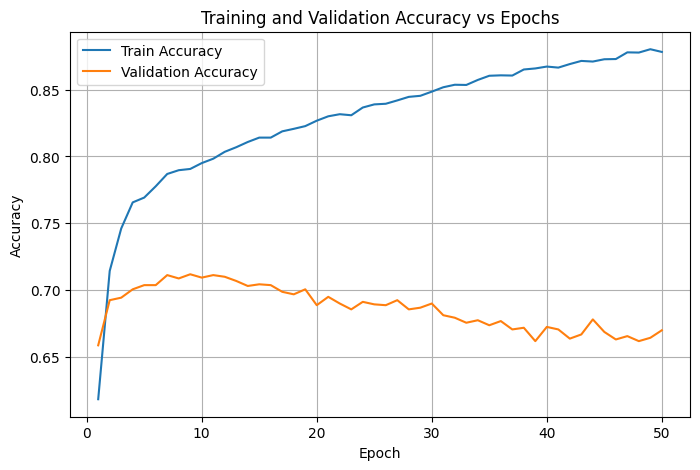

In [10]:
# plot train and val acc as a function of epochs
# your code here


plt.figure(figsize=(8, 5))

epochs_range = range(1, len(history["accuracy"]) + 1)

plt.plot(epochs_range, history["accuracy"], label="Train Accuracy")
plt.plot(epochs_range, history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy vs Epochs")
plt.legend()
plt.grid(True)

plt.show()


Based on the visualisation above, the ideal number of epochs seems to be around 10, because it is at that moment that the validation accuracy is the highest (before overfitting)

In [11]:
# evaluate on train and test and print accuracy results
# your code here


# Reset model
def reset_weights(m):
    if isinstance(m, nn.Linear):
        m.reset_parameters()

torch.manual_seed(109)
np.random.seed(109)
NN_model.apply(reset_weights)

# Build FULL training dataset + DataLoader
X_fulltrain_tensor = torch.tensor(X_train_std.values, dtype=torch.float32)
y_fulltrain_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
fulltrain_ds = TensorDataset(X_fulltrain_tensor, y_fulltrain_tensor)

batch_size = 64
train_loader = DataLoader(fulltrain_ds, batch_size=batch_size, shuffle=True)

# Reset loss + optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(NN_model.parameters(), lr=1e-3)

# Train for 10 epochs on FULL training set
epochs = 10
for epoch in range(epochs):
    NN_model.train()
    loss_sum = 0.0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = NN_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        total += yb.size(0)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train loss: {loss_sum/total:.4f}")

# Evaluate on TEST set
NN_model.eval()
with torch.no_grad():
    preds_train = NN_model(X_fulltrain_tensor)
    train_acc = ((preds_train >= 0.5).float() == y_fulltrain_tensor).float().mean().item()

    X_test_tensor = torch.tensor(X_test_std.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

    preds_test = NN_model(X_test_tensor)
    test_acc = ((preds_test >= 0.5).float() == y_test_tensor).float().mean().item()

print(f"\nFinal Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 01/10 | Train loss: 0.6619
Epoch 02/10 | Train loss: 0.5620
Epoch 03/10 | Train loss: 0.5205
Epoch 04/10 | Train loss: 0.5023
Epoch 05/10 | Train loss: 0.4906
Epoch 06/10 | Train loss: 0.4803
Epoch 07/10 | Train loss: 0.4701
Epoch 08/10 | Train loss: 0.4618
Epoch 09/10 | Train loss: 0.4541
Epoch 10/10 | Train loss: 0.4471

Final Training Accuracy: 0.8055
Test Accuracy: 0.7030


<div class='exercise-r'>

### 1.3 Bootstrap prediction intervals

In CS1090A, we saw how we could use MCMC to perform Bayesian inference on the parameters of linear and logistic regression models. This gave us access not only to samples from the posterior distribution (betas) but we could also generate samples from the posterior predictive distribution (data). The posterior predictive can be used to represent our uncertainty about a given prediction, $\hat{y}$.

We'd like to do something similar for our neural network here so that we can quantify the uncertainty in our predictions. But there are some problems. First, we haven't (explicitly) specified any priors on the network weights. Second, and more serious, neural networks have many, many parameters. Far too many for MCMC to be a viable approach. Sampling in such a high dimensional space is simply intractable.

Bootstrap to the rescue!

Using the same network architecture as `NN_model` (layers, nodes, activations, etc.) and the scaled data you used with that model, create multiple training sets through bootstrapping, fitting a separate neural network model to each bootstrapped set of data (the number of bootstraped *datasets*, $n$, should be at least 50). For each of the $n$ models, make predictions on the test data. Randomly select 8 test observations and on 8 subplots, plot the distribution of the $n$ predicted probabilities with the 95% prediction intervals clearly marked and reported in each subplot and the **actual** class of each observation included in each subplot's title for easy reference.
    
Interpret what you see in 3-5 sentences.

**NOTE:** The code for this problem can take an extremely long time to execute. Please feel free to use the `progressbar` function provided below to visually track the progress of your bootstraps.

<a id="q13"></a>


</div>

In [12]:
def progressbar(n_step, n_total):
    """Prints self-updating progress bar to stdout to track for-loop progress

    There are entire 3rd-party libraries dedicated to custom progress-bars.
    A simple function like this is often more than enough to get the job done.

    :param n_total: total number of expected for-loop iterations
    :type n_total: int
    :param n_step: current iteration number, starting at 0
    :type n_step: int

    .. example::

        for i in range(n_iterations):
            progressbar(i, n_iterations)

    .. source:

        This function is a simplified version of code found here:
        https://stackoverflow.com/questions/3160699/python-progress-bar/15860757#15860757
    """
    n_step = n_step + 1
    barlen = 50
    progress = n_step / n_total
    block = int(round(barlen * progress))
    status = ""
    if n_step == n_total:
        status = "Done...\r\n\n"
    text = "\r [{0}] {1}/{2} {3}".format(
        "=" * block + "-" * (barlen - block),
        n_step,
        n_total,
        status,
    )
    sys.stdout.write(text)
    sys.stdout.flush()

In [13]:
%%time
# Bootstrap and train your networks and get predictions on X test
# your code here

n_boot = 50
epochs = 10
batch_size = 64
lr = 1e-3

# Train and test data
X_train_np = X_train_std.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1)

X_test_np = X_test_std.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32).reshape(-1, 1)

n_train = X_train_np.shape[0]
n_test = X_test_np.shape[0]
dim = X_train_np.shape[1]

# For storage of probabilities
boot_test_probs = np.zeros((n_boot, n_test), dtype=np.float32) # shape: (n_boot, n_test)

criterion = nn.BCELoss()

for b in range(n_boot):
    progressbar(b, n_boot)

    # Bootstrap sample indices (sample WITH replacement)
    idx = np.random.choice(n_train, size=n_train, replace=True) # generate bootstrap indices

    Xb = torch.tensor(X_train_np[idx], dtype=torch.float32)
    yb = torch.tensor(y_train_np[idx], dtype=torch.float32)

    boot_ds = TensorDataset(Xb, yb)
    boot_loader = DataLoader(boot_ds, batch_size=batch_size, shuffle=True)

    # Fresh model (same architecture as NN_model)
    model = nn.Sequential(
        nn.Linear(dim, 15),
        nn.ReLU(),
        nn.Linear(15, 15),
        nn.ReLU(),
        nn.Linear(15, 1),
        nn.Sigmoid()
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train
    for epoch in range(epochs):
        model.train()
        for xb_batch, yb_batch in boot_loader:
            optimizer.zero_grad()
            preds = model(xb_batch)
            loss = criterion(preds, yb_batch)
            loss.backward()
            optimizer.step()

    # Predict probabilities on test
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
        probs = model(X_test_tensor).numpy().reshape(-1)
        boot_test_probs[b, :] = probs


 [==================================================] 50/50 Done...

CPU times: user 12min 6s, sys: 976 ms, total: 12min 7s
Wall time: 2min 2s


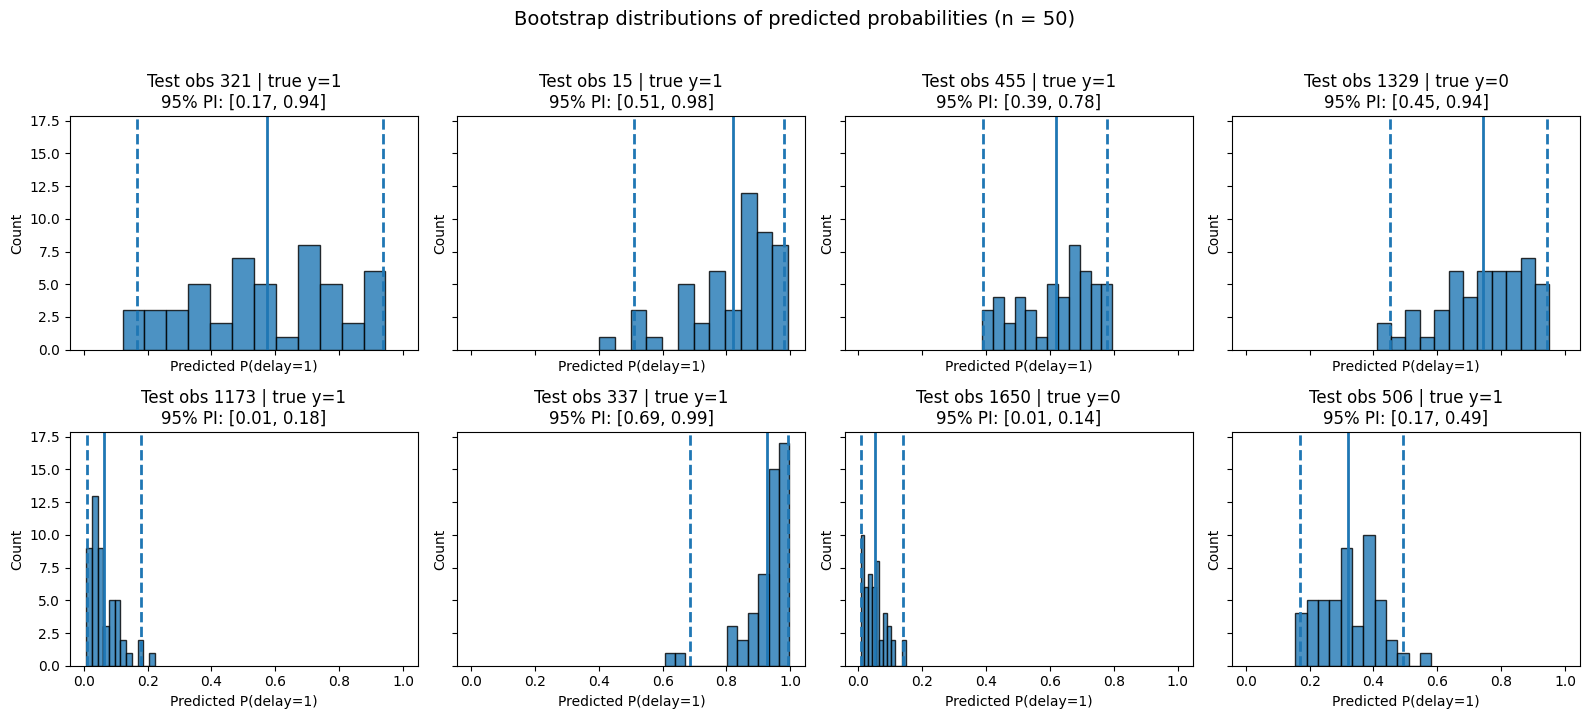

In [14]:
# generate your plot
# your code here

# Choose 8 random test observations
chosen_idx = np.random.choice(n_test, size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.ravel()

for ax, j in zip(axes, chosen_idx):
    probs_j = boot_test_probs[:, j]  # n_boot probabilities for test obs j

    lo, hi = np.percentile(probs_j, [2.5, 97.5])
    mean_p = probs_j.mean()
    y_true = int(y_test_np[j, 0])

    # histogram of bootstrap predicted probabilities
    ax.hist(probs_j, bins=12, edgecolor="black", alpha=0.8)

    # mark mean and 95% interval
    ax.axvline(lo, linestyle="--", linewidth=2)
    ax.axvline(hi, linestyle="--", linewidth=2)
    ax.axvline(mean_p, linewidth=2)

    ax.set_title(f"Test obs {j} | true y={y_true}\n95% PI: [{lo:.2f}, {hi:.2f}]")
    ax.set_xlabel("Predicted P(delay=1)")
    ax.set_ylabel("Count")

plt.suptitle("Bootstrap distributions of predicted probabilities (n = {})".format(n_boot), y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


The bootstrap results show that prediction uncertainty varies across test observations. Some flights have narrow 95% prediction intervals concentrated near 0 or 1, meaning the model is confident and stable across different bootstrap samples. Other flights have much wider intervals, sometimes crossing 0.5, which indicates high uncertainty and disagreement between bootstrap models. In a few cases, the model is confidently wrong, showing that bootstrap helps detect uncertainty but does not correct systematic bias in the model. Overall, bootstrapping provides a practical way to quantify prediction uncertainty for neural networks without using a fully Bayesian approach.

<div class='exercise-r'>

### 1.4 Build an "abstain" bagging model

Using the probability distribution of the predictions obtained from the bootstrapped samples above, we can evaluate how confident we should be in our bagged (i.e. bootstrap-aggregated) predictions for each test observation.

To accomplish this, you will first calculate a metric we'll call the **Posterior Prediction Dissent (PPD)** related to the proportion of predictions a given test observation receives for the minority opinion. Some examples: if 10% of the bootstrapped models predict $\hat{y} = 0$ with the remaining 90% predicting $\hat{y}=1$, then the $PPD=0.1$. When a bagged prediction's $PPD=0$, all predictions are compatible (i.e. all bootstrapped probabilities for that test observation are on the same side of $\hat{p}=0.5$). Likewise, when the $PPD=0.5$, half of the bootstrapped predictions for that test observation are $\hat{y}=0$, and the other half are $\hat{y}=1$. After calculating your $PPD$ values for all test observations, you should have $n=2000$ $PPD$ values (i.e. one for each test observation).

Next, to get more accurate predictions, we can create an **abstain** model that will abstain from making a prediction for a particular observation if some defined threshold for lack-of-confidence (i.e. maximum permissible $PPD$ value) is crossed. (If you'd like to learn more about abstain models, you can read more [here](https://openreview.net/forum?id=rJxF73R9tX).)

Let's explore how your resulting test accuracies might change by using your bootstrapped prediction results from question 1.3 for an **abstain bagging model** (i.e. a bootstrap aggregated model where some test observations are simply not predicted based on a given $PPD$ threshold). You can make your abstain model *stricter* by using smaller $PPD$ threshold values.

- Print the test accuracy for your **bagging model** predictions from question 1.3 using predictions for all 2,000 of our test observations.

- Plot the test accuracies for an **abstain bagging model** using your predictions from question 1.3 as a function of increasing $PPD$.

- Also, plot the proportion of test observations not abstained (i.e. the proportion of those predicted) for your **abstain bagging model** as a function of increasing $PPD$.

- Interpret what you see in 3-5 sentences.

**NOTE**: You should observe that as $PPD$ decreases (more confident predictions), you must also compromise on the number of points that your abstain model is permitted to predict on.

**HINT:**
- What is the range of values PPD can take on? Is it the same as the range of our predictions themselves?
- When calculating accuracies, you should only consider those observations that received predictions (i.e., not the abstained observations)
</div>

Bagging model test accuracy (no abstain, all 2000): 0.7175


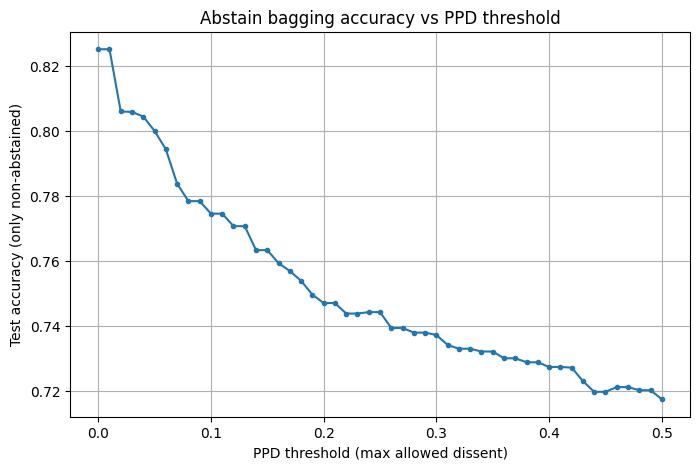

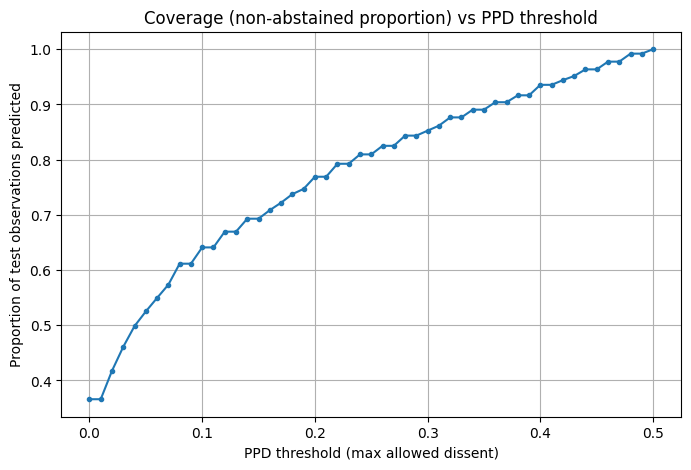

In [15]:
# your code here

y_test_np = y_test.values.astype(int)
n_boot, n_test = boot_test_probs.shape

# Convert bootstrap probabilities into bootstrap class predictions (0/1) with 0.5 threshold
boot_test_preds = (boot_test_probs >= 0.5).astype(int)

vote_frac_1 = boot_test_preds.mean(axis=0) # fraction voting 1 for each test obs
bag_pred = (vote_frac_1 >= 0.5).astype(int) # majority vote

PPD = np.minimum(vote_frac_1, 1 - vote_frac_1)   # PPD = proportion of predictions in the minority opinion

bag_acc_all = (bag_pred == y_test_np).mean() # number of good prediction (majority opition vs true value)
print(f"Bagging model test accuracy (no abstain, all {n_test}): {bag_acc_all:.4f}")

# Abstain model: evaluate accuracy only on points with PPD <= threshold
thresholds = np.linspace(0.0, 0.5, 51) # PPD is in [0, 0.5]

acc_by_thr = []
prop_predicted_by_thr = []

for t in thresholds:
    mask = (PPD <= t)  # list of booleans
    prop_predicted = mask.mean() # gives % of predicted
    prop_predicted_by_thr.append(prop_predicted)

    if mask.sum() == 0:
        acc_by_thr.append(np.nan)     # no predictions at all
    else:
        acc = (bag_pred[mask] == y_test_np[mask]).mean()
        acc_by_thr.append(acc)


# Plot test accuracy vs PPD threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, acc_by_thr, marker="o", markersize=3)
plt.xlabel("PPD threshold (max allowed dissent)")
plt.ylabel("Test accuracy (only non-abstained)")
plt.title("Abstain bagging accuracy vs PPD threshold")
plt.grid(True)
plt.show()


# Plot proportion predicted vs PPD threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, prop_predicted_by_thr, marker="o", markersize=3)
plt.xlabel("PPD threshold (max allowed dissent)")
plt.ylabel("Proportion of test observations predicted")
plt.title("Coverage (non-abstained proportion) vs PPD threshold")
plt.grid(True)
plt.show()


The bagging model (no abstaining) achieves a test accuracy of about 0.716. When we use a small PPD threshold, the model only predicts on the most “agreed-upon” cases (coverage is low), but accuracy is higher (around 0.82). As the PPD threshold increases, the model predicts on more observations (coverage increases toward 1), but accuracy steadily decreases and approaches the full-coverage bagging accuracy. This shows a clear trade-off: stricter abstaining improves accuracy but forces the model to abstain on more test points.

<!-- <div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA"> -->

## PART 2 [50 pts]: The Quick, Draw!  Kaggle competition

### Problem Statement

Artificial neural networks (ANNs) are prone to overfitting, learning patterns specific to the training data that do not generalize to new data.

There are several methods to reduce ANN generalization error.

One approach is to use an architecture just barely wide or deep enough to fit the data. The idea here is that smaller networks are less expressive and thus less likely to overfit the data.

However, it is difficult to know a priori the correct size of the ANN, and it is computationally costly to hunt for the correct size. Given this, other methodologies are used to prevent overfitting and improve ANNs' generalizability. These methodologies, like other techniques that combat overfitting, fall under the umbrella term of "regularization."

### The Quick, Draw! Dataset

![](./img/quickdrawpreview.jpg)

For this problem, we will be working with a modified version of the [The Quick, Draw! Dataset](https://github.com/googlecreativelab/quickdraw-dataset), which is a large database of 50 million drawings across 345 categories, collected from players of the game [Quick, Draw!](https://quickdraw.withgoogle.com/).

For this homework, we will simplify the problem by using only 120,000 images across 10 different classes for training (this includes the data you will use for validation) and a test set of 30,000 images.

### Downloading the Data Files

**The required `train.csv` and `test.csv` data files are available on [the "Data" tab of the CS1090B HW1 Kaggle Competition website](https://www.kaggle.com/t/9b2ecc1d068c4cc592e4d3f4116b38dc). They are also included with this assignment in `data/quickdraw.zip`. (DO NOT USE DATA FROM ANY OTHER SOURCE!)**

Here's a brief description of the data files:

- `train.csv` is our training dataset and the `label` column contains our response class. The 784 other columns correspond to the pixel values of the 28x28 dimension image.  `train.csv` has 120,000 samples.

- `test.csv` file mirrors the structure of the `train.csv` file **without** the class label column. We have added another column `id`. `id` is a unique identifier for each sample in the test set. This ID is crucial for mapping your model's predictions back to the corresponding samples when submitting your results to Kaggle. `test.csv` has 30,000 samples.

- Since the `test.csv` does not include the true labels, it is used exclusively for generating predictions that you'll submit to Kaggle for evaluation.  Your task is to predict the class labels for each sample in `test.csv` and submit these predictions in the required format.


Kaggle leaderboard scores are accuracy scores calculated by Kaggle when you upload your predictions on this test set.

- `sample_submission.csv` is the format that kaggle will accept. The uploaded `.csv` must contain 2 columns. The first column must be named `id` and needs to contain the test observation index numbers for each prediction, the second must be named `label` and needs to contain your class predictions (i.e. 'cat', 'dog' etc) for each corresponding test observation index location.

### CS1090B Kaggle Competition

**ACCESS AND JOIN THE COMPETITION**:

**You need to create an account on Kaggle and [join the competition via this link](https://www.kaggle.com/t/9b2ecc1d068c4cc592e4d3f4116b38dc). This is a limited participation competition. Please DO NOT share this link.**

**For more information on the rules** governing this CS1090B Kaggle competition, please see below and also review the modeling restrictions DOS and DON'TS outlined below.

**IMPORTANT NOTES ABOUT SCORING**:

- The **public leaderboard** on Kaggle displays your performance on only 30% of the test set.

- After the competition is complete, the **private leaderboard** will show your performance on the remaining 70% of the test set.

- Question 2.3.7 is worth 30 points (the entire notebook is scored out of 100). Points for this questions will be awarded based on the **private leaderboard** accuracy score using the scoring function defined in [this notebook](https://colab.research.google.com/drive/1BqvxSDXwm4wfns1gfVGsEiV_fx_wZjOG?usp=sharing).

**ADDITIONAL COMPETITION RULES:**

- Multiple Kaggle submissions are permitted (with a maximum of 5 submissions per team per-day), **just note that you will need to choose, on Kaggle, the ONE single submission to use for final scoring prior to the final HW1 submission deadline**, and **your submitted notebook MUST contain the matching code and model that generated your ONE chosen submission.**


- **To repeat this point, the version of your final HW1 notebook submitted on Canvas MUST contain the same code and exact same model used to generate your ONE chosen Kaggle submission.** (TFs may rerun your notebook code to ensure comparable final leaderboard results.)


- **Please do not manually label your submissions.** In other words, the labels should only be the outcome of your model.


- **No external data are allowed**, you MUST USE ONLY the training and test data downloaded via the "Data" tab of the CS1090B competition page linked above.


- **Do not** create multiple accounts on Kaggle.


<div class='exercise-r'>

### 2.1 Download and visualize the data

- The data was included with the HW1 zip but can also be downloaded from [the competition page](https://www.kaggle.com/t/9b2ecc1d068c4cc592e4d3f4116b38dc).
- You will utilize `test.csv` in question 2.3.6.
- Load the training data and use the matplotlib function `imshow` to display 25 samples  from each of the 10 classes from the training set. Total of 250 samples, 10 rows of 25 images each.
- You are responsible for any preprocessing you deem necessary to help in your prediction task.

</div>

Any NaNs in entire dataset? False
Shape: (120000, 785)
Classes: ['apple' 'butterfly' 'car' 'cat' 'dog' 'duck' 'face' 'skull' 'swan' 'tree']


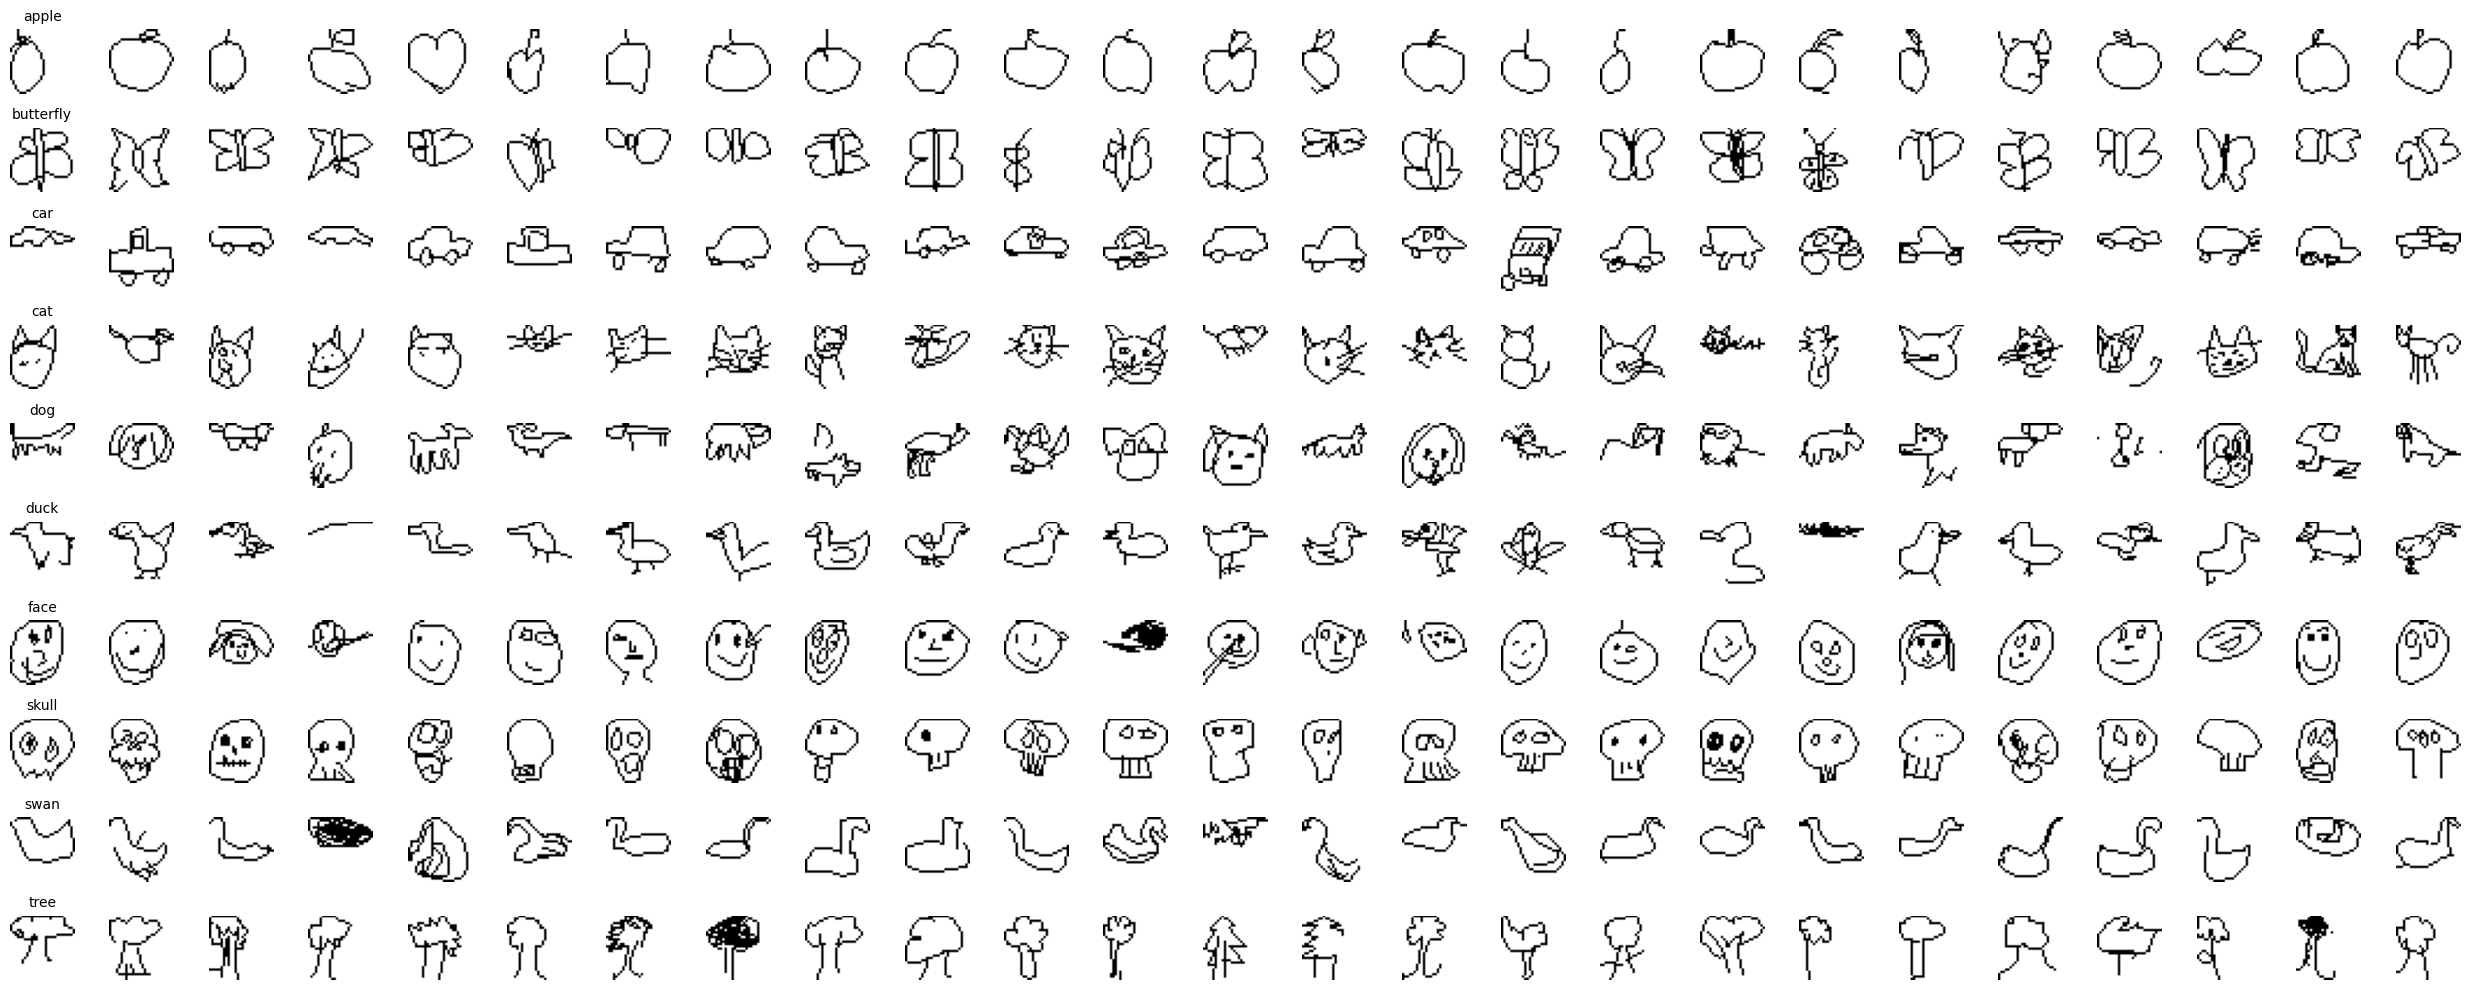

In [16]:
# your code here

# Training data
train_df = pd.read_csv("quickdraw/train.csv")
print("Any NaNs in entire dataset?", train_df.isna().any().any())
print("Shape:", train_df.shape)

y = train_df["label"].values
X = train_df.drop(columns=["label"]).values

X = X.astype("float32") / 255.0 # Normalize pixel values
X_images = X.reshape(-1, 28, 28) # Reshape into images (28x28)

# Get unique classes (sorted for consistent ordering)
classes = np.sort(np.unique(y))
print("Classes:", classes)

# Create figure: 10 rows (classes), 25 columns (samples)
fig, axes = plt.subplots(nrows=10, ncols=25, figsize=(25, 10))

for row_idx, cls in enumerate(classes):

    # Get indices of this class
    class_indices = np.where(y == cls)[0]

    # Randomly choose 25 samples from this class
    selected_indices = np.random.choice(class_indices, 25, replace=False)

    for col_idx, img_idx in enumerate(selected_indices):
        axes[row_idx, col_idx].imshow(X_images[img_idx], cmap="gray")
        axes[row_idx, col_idx].axis("off")

        # Label first image in each row
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(f"{cls}", fontsize=10)

plt.tight_layout()
plt.show()


<div class='exercise-r'>

### 2.2  Overfit an ANN

Build and fit a fully-connected network (FCN) with the architecture given below using `torch` and assign it to a variable called `model_overfit`:

* **Model type:** fully-connected network (FCN / MLP) for **10-class** classification
* **Hidden layers:** 3 fully-connected hidden layers
* **Hidden units:** 10,000 -> 10,000 -> 10,000
* **Hidden activation:** ReLU
* **Output layer:** a fully-connected layer with **10 outputs** producing **logits** (unnormalized class scores)
* **Training loss:** **multiclass cross-entropy** (negative log-likelihood of the correct class under a softmax over logits).
* **Optimizer:** Adam with default settings (no tuning)
* **Epochs:** 20
* **Batch size:** 128
* **Validation split:** 0.2 (hold out 20% of the training set as validation)

    
This ANN, when trained on the dataset, will overfit to the training set. Plot the training accuracy and validation accuracy (the x-axis should represent the number of epochs, and the y-axis should represent the accuracy). Explain how you can tell the model is overfitting.

</div>


Epoch 1/20
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...


Epoch 01/20 | loss: 1.4413, acc: 0.5370 | val_loss: 1.0369, val_acc: 0.6499

Epoch 2/20
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...


Epoch 02/20 | loss: 0.9358, acc: 0.6872 | val_loss: 0.8305, val_acc: 0.7222

Epoch 3/20
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...


Epoch 03/20 | loss: 0.8076, acc: 0.7294 | val_loss: 0.7902, val_acc: 0.7342

Epoch 4/20
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...


Epoch 04/20 | loss: 0.7423, acc: 0.7494 | val_loss: 0.7314, val_acc: 0.7561

Epoch 5/20
 [==========

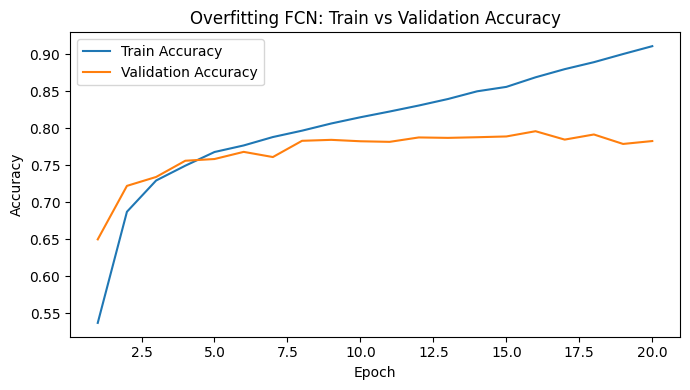

In [17]:
# your code here

class_to_idx = {c: i for i, c in enumerate(classes)}
y_int = np.array([class_to_idx[label] for label in y], dtype=np.int64)

X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y_int)


# Build NN
dim = X_tensor.shape[1]

model_overfit = nn.Sequential(
    nn.Linear(dim, 10000),
    nn.ReLU(),
    nn.Linear(10000, 10000),
    nn.ReLU(),
    nn.Linear(10000, 10000),
    nn.ReLU(),
    nn.Linear(10000, 10)   # logits for 10 classes (NO softmax here)
)

# Split train/validation (80/20)
full_dataset = TensorDataset(X_tensor, y_tensor)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_set, val_set = random_split(full_dataset, [n_train, n_val])


# Mini-batches
batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)


# Loss and optimizer
criterion = nn.CrossEntropyLoss()   # multiclass cross-entropy
optimizer = optim.Adam(model_overfit.parameters())  # default Adam settings


# Training loop
epochs = 20
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_overfit = model_overfit.to(device)

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # TRAINING
    model_overfit.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device)
        yb = yb.to(device)

        progressbar(batch_idx, len(train_loader))

        optimizer.zero_grad()
        logits = model_overfit(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        pred_labels = torch.argmax(logits, dim=1)
        train_correct += (pred_labels == yb).sum().item()
        train_total += yb.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    print("\nValidation:")

    # VALIDATION
    model_overfit.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(val_loader):
            xb = xb.to(device)
            yb = yb.to(device)

            progressbar(batch_idx, len(val_loader))

            logits = model_overfit(xb)
            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)
            pred_labels = torch.argmax(logits, dim=1)
            val_correct += (pred_labels == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"\nEpoch {epoch+1:02d}/{epochs} | "
        f"loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
    )


# Plot training vs validation accuracy
plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), history["accuracy"], label="Train Accuracy")
plt.plot(range(1, epochs+1), history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overfitting FCN: Train vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


The model is overfitting because training accuracy continues to increase throughout training (reaching about 90%), while validation accuracy plateaus around 79%. The widening gap between training and validation performance indicates that the model is memorizing patterns specific to the training data that do not generalize to unseen data.

### 2.3 Improving the Network

#### 2.3.1 Enhancing Feature Extraction with Fourier Transforms
**[209 requirement; optional for others]**

Neural networks can learn useful representations of their inputs while simultaneously solving tasks like classification. This process, called **representation learning**, can be seen as a form of feature extraction. However, incorporating **explicit feature transformations** can still improve performance. One such transformation is the **Fourier Transform (FT)**, which decomposes an image into its frequency components. This alternative representation can highlight patterns that may not be easily captured in the pixel space. The **Fast Fourier Transform (FFT)** is an efficient algorithm for computing the FT.

Your task:

* **Implement a custom layer** (as a `torch.nn.Module`) that applies the **FFT** to its input.
* **Incorporate this layer** into a neural network architecture for classifying the "Quick, Draw!" dataset.
* **Describe your approach**: Explain where and how you added the FFT layer, your reasoning behind it, and whether it improved performance compared to the previous model.

**Hints**

* In PyTorch, “custom layers” are typically implemented by subclassing `torch.nn.Module` and defining `forward()`.
* The 2D FFT returns complex values; you’ll need to decide how to represent them as real-valued features (e.g., real/imag parts or magnitude).

You may find the following documentation helpful:

* `torch.fft.fft2` (2D FFT): [https://docs.pytorch.org/docs/stable/generated/torch.fft.fft2.html](https://docs.pytorch.org/docs/stable/generated/torch.fft.fft2.html)
* `torch.view_as_real` (represent complex tensors as real/imag): [https://docs.pytorch.org/docs/stable/generated/torch.view_as_real.html](https://docs.pytorch.org/docs/stable/generated/torch.view_as_real.html)
* Custom `nn.Module` example/tutorial: [https://docs.pytorch.org/tutorials/beginner/examples_nn/polynomial_module.html](https://docs.pytorch.org/tutorials/beginner/examples_nn/polynomial_module.html)
* `torch.cat` (concatenate features): [https://docs.pytorch.org/docs/stable/generated/torch.cat.html](https://docs.pytorch.org/docs/stable/generated/torch.cat.html)

⚠️ **Note:** For 209 students, this question is worth only 5 points out of the 100 possible points in the notebook, so allocate your time accordingly. Non-209 students will *not* be awarded bonus points for completing this section (though doing so may improve Kaggle performance).

Using device: cuda

Epoch 1/20
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...

Epoch 01/20 | loss: 0.8942, acc: 0.7125 | val_loss: 0.7010, val_acc: 0.7696

Epoch 2/20
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...

Epoch 02/20 | loss: 0.5286, acc: 0.8240 | val_loss: 0.6796, val_acc: 0.7822

Epoch 3/20
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...

Epoch 03/20 | loss: 0.3621, acc: 0.8767 | val_loss: 0.7366, val_acc: 0.7806

Epoch 4/20
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...

Epoch 04/20 | loss: 0.2538, acc: 0.9118 | val_loss: 0.8958, val_acc: 0.7711

Epoch 5/

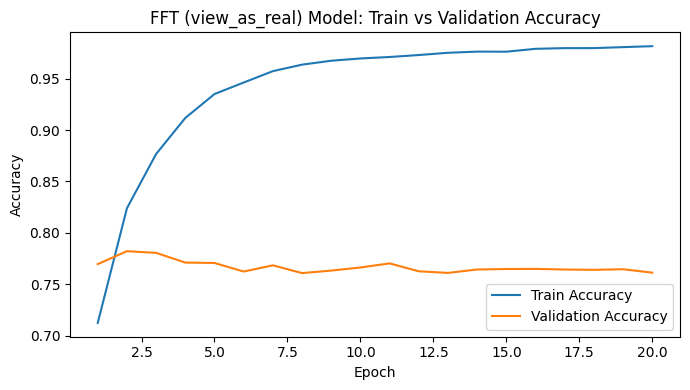

In [18]:
# your code here


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data
classes = np.sort(np.unique(y))
class_to_idx = {c: i for i, c in enumerate(classes)}
y_int = np.array([class_to_idx[label] for label in y], dtype=np.int64)

X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y_int)


# Train data
full_dataset = TensorDataset(X_tensor, y_tensor)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_set, val_set = random_split(full_dataset, [n_train, n_val])

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)


# Custom FFT layer as nn.Module
class FFTLayer(nn.Module):
    """
    Applies 2D FFT to input images and returns real-valued features using view_as_real.
    Input:  (B,784) float
    Output: (B,1568) float  (real/imag for each of 28*28 frequencies)
    """
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # x: (B,784)
        x_img = x.view(-1, 28, 28) # (B,28,28)
        Xf = torch.fft.fft2(x_img) # complex (B,28,28)
        ri = torch.view_as_real(Xf) # (B,28,28,2) last dim: [real, imag]
        feats = ri.view(x.size(0), -1) # (B, 28*28*2 = 1568)
        return feats


# Model that uses FFT features
USE_CONCAT = True  # True: concatenate pixels + FFT(real/imag); False: FFT only

fft_layer = FFTLayer()

in_dim = 1568 + 784 if USE_CONCAT else 1568

model_fft = nn.Sequential(
    fft_layer,  # <-- FFT layer goes FIRST
    # After this layer, the tensor is (B,1568). But if we want concat, we do it outside nn.Sequential.
)

# Since concatenation needs the original x too, we wrap the classifier separately:
classifier = nn.Sequential(
    nn.Linear(in_dim, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 10)  # logits
)

model_fft = model_fft.to(device)
classifier = classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(model_fft.parameters()) + list(classifier.parameters()))  # default Adam


# 5) Training loop
epochs = 20
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # TRAIN
    model_fft.train()
    classifier.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        fft_feats = model_fft(xb) # (B,1568)

        progressbar(batch_idx, len(train_loader))

        if USE_CONCAT:
            feats = torch.cat([xb, fft_feats], dim=1) # (B, 784+1568)
        else:
            feats = fft_feats # (B,1568)

        logits = classifier(feats)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        pred = torch.argmax(logits, dim=1)
        train_correct += (pred == yb).sum().item()
        train_total += yb.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    print("\nValidation:")


    # VAL
    model_fft.eval()
    classifier.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(val_loader):
            xb = xb.to(device)
            yb = yb.to(device)

            fft_feats = model_fft(xb)

            progressbar(batch_idx, len(val_loader))

            if USE_CONCAT:
                feats = torch.cat([xb, fft_feats], dim=1)
            else:
                feats = fft_feats

            logits = classifier(feats)
            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)
            pred = torch.argmax(logits, dim=1)
            val_correct += (pred == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
    )


# 6) Plot
plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), history["accuracy"], label="Train Accuracy")
plt.plot(range(1, epochs+1), history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FFT (view_as_real) Model: Train vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


I implemented a custom Fourier feature layer as a torch.nn.Module (FFTLayer) and placed it at the beginning of the network so it transforms the raw pixel input before the fully connected layers. Each input vector of length 784 is reshaped to 28×28 and transformed using torch.fft.fft2 to move from the spatial domain to the frequency domain. Since the FFT output is complex-valued, I used torch.view_as_real to separate real and imaginary parts, producing 28×28×2 = 1568 real-valued features per image. These FFT features were then either used directly or concatenated with the original pixel features using torch.cat, allowing the classifier to leverage both spatial and frequency information.

In practice, this FFT-based model did not improve validation performance compared to the previous (non-FFT) overfitting FCN. The FFT model achieved a peak validation accuracy of about 0.76–0.77 during the first few epochs, but validation performance slightly decreased afterward, finishing around 0.76 after 20 epochs.

At the same time, training accuracy kept increasing and reached about 0.98, while training loss became extremely small. The large and persistent gap between training and validation accuracy indicates strong overfitting.

A likely explanation is that separating real and imaginary FFT components significantly increases input dimensionality and model capacity, allowing the network to memorize the training data without improving generalization. The frequency-domain representation may also introduce phase-related variations that are difficult for a simple fully connected network to exploit effectively.

<div class='exercise-r'>

#### 2.3.2  Kaggle Competition

Create an ANN and use it to compete on Kaggle.
    
**DON'TS**

- **No CNNs, transfer learning, RNNs, ensembles, or any ensembles/stacking.**

- **DO NOT manually label your submissions.** In other words, the labels should only be the outcome of your model.

- **DO NOT use any external data.** Please use ONLY the specific dataset provided to you for training your model and for generating your test predictions.

**DOS**

 - **YOU CAN change the** number of epochs, batch size, optimizer, and of course, add elements that can help to regularize your model.
 - **YOU CAN** do data augmentation using the provided training data.
 - **YOU CAN** make use of your custom Fourier Transform layer from the previous question.

**IMPORTANT: YOU MUST** ensure that the version of the code and model in your final submitted notebook is the **EXACT SAME** code and model used to generate your Kaggle submission. TFs may run your submitted model to ensure comparable results.
</div>

In [19]:
class_to_idx = {c: i for i, c in enumerate(classes)}
y_int = np.array([class_to_idx[label] for label in y], dtype=np.int64)

X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y_int)


# Build NN
dim = X_tensor.shape[1]

model_overfit = nn.Sequential(
    nn.Linear(dim, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)   # logits for 10 classes (NO softmax here)
)

# Split train/validation (80/20)
full_dataset = TensorDataset(X_tensor, y_tensor)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_set, val_set = random_split(full_dataset, [n_train, n_val])


# Mini-batches
batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)


# Loss and optimizer
criterion = nn.CrossEntropyLoss()   # multiclass cross-entropy
optimizer = optim.Adam(model_overfit.parameters(), lr=(5e-4), weight_decay=5e-5)  # L2 regularization + lower learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5)


# Training loop
epochs = 80
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

best_val_loss = float("inf")
best_state = None
patience = 5
patience_counter = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_overfit = model_overfit.to(device)

def random_translate(img, max_shift=2):
          B = img.size(0)
          sx = torch.randint(-max_shift, max_shift+1, (B,), device=img.device)
          sy = torch.randint(-max_shift, max_shift+1, (B,), device=img.device)

          out = torch.zeros_like(img)
          for i in range(B):
            x0 = max(0, sx[i].item()); x1 = 28 + min(0, sx[i].item())
            y0 = max(0, sy[i].item()); y1 = 28 + min(0, sy[i].item())
            out[i, :, x0:x1, y0:y1] = img[i, :, x0-sx[i].item():x1-sx[i].item(), y0-sy[i].item():y1-sy[i].item()]
          return out


for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # TRAINING
    model_overfit.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device)
        yb = yb.to(device)

        progressbar(batch_idx, len(train_loader))

        if model_overfit.training:
          img = xb.view(-1, 1, 28, 28)
          img = random_translate(img, max_shift=2)
          xb = img.view(-1, 784)


        optimizer.zero_grad()
        logits = model_overfit(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        pred_labels = torch.argmax(logits, dim=1)
        train_correct += (pred_labels == yb).sum().item()
        train_total += yb.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total


    print("\nValidation:")

    # VALIDATION
    model_overfit.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(val_loader):
            xb = xb.to(device)
            yb = yb.to(device)

            progressbar(batch_idx, len(val_loader))

            logits = model_overfit(xb)
            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)
            pred_labels = torch.argmax(logits, dim=1)
            val_correct += (pred_labels == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    if val_loss < best_val_loss - 1e-4 :
      best_val_loss = val_loss
      best_state = {k: v.detach().cpu().clone() for k, v in model_overfit.state_dict().items()}
      patience_counter = 0
    else:
      patience_counter += 1
      if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best val_loss={best_val_loss:.4f}")
        break


    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"\nEpoch {epoch+1:02d}/{epochs} | "
        f"loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
    )


if best_state is not None:
  model_overfit.load_state_dict(best_state)




Epoch 1/80
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...


Epoch 01/80 | loss: 1.6848, acc: 0.4103 | val_loss: 1.3178, val_acc: 0.5480

Epoch 2/80
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...


Epoch 02/80 | loss: 1.3146, acc: 0.5530 | val_loss: 1.0806, val_acc: 0.6356

Epoch 3/80
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...


Epoch 03/80 | loss: 1.1396, acc: 0.6127 | val_loss: 0.9671, val_acc: 0.6732

Epoch 4/80
 [==================================================] 750/750 Done...


Validation:
 [==================================================] 188/188 Done...


Epoch 04/80 | loss: 1.0269, acc: 0.6514 | val_loss: 0.9108, val_acc: 0.6934

Epoch 5/80
 [==========

<div class='exercise-r'>

#### 2.3.3 Trace Plots
Plot your model's training accuracy and validation accuracy as a function of epochs.




</div>

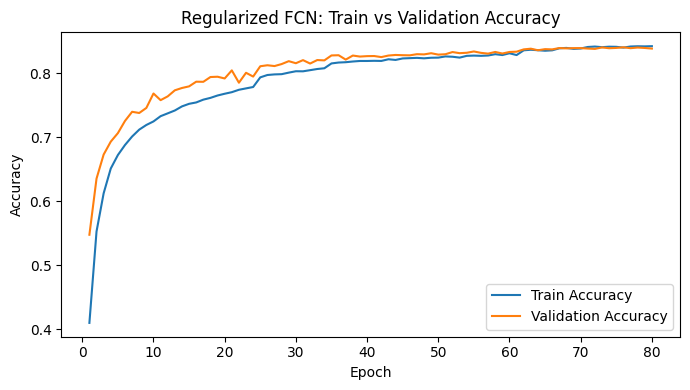

In [20]:
# Plot training vs validation accuracy
n_epochs_ran = len(history["accuracy"])

plt.figure(figsize=(7,4))
plt.plot(range(1, n_epochs_ran + 1), history["accuracy"], label="Train Accuracy")
plt.plot(range(1, n_epochs_ran + 1), history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Regularized FCN: Train vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

<div class='exercise-r'>

#### 2.3.4 Error analysis that remains reproducible

Accuracy alone won’t tell you what your model is *getting wrong*, or whether the mistakes are random vs. systematic. In this question you’ll diagnose failure modes by looking at cases where the model is **wrong but very confident**—often the most revealing errors.

**Important reproducibility requirement:** you will likely keep iterating on your model after this point, but your error analysis should remain valid and rerunnable later. To do that, pick a “snapshot” model (e.g., your current best at this stage) and make it reproducible: **save its weights (or otherwise freeze it)** and make sure you can **reload it** to reproduce the same validation predictions. If you later improve your model for Kaggle, you should still be able to rerun this analysis on the snapshot without it silently changing.

Using your **validation set**, identify at least **12** examples where the snapshot model’s prediction is **incorrect** but its predicted probability for the chosen class is **high** (e.g., ≥ 0.90; if needed, choose a threshold that yields ~10–20 examples and report it). Display these examples in a grid, annotating **true label**, **predicted label**, and **confidence**.

In **5–8 sentences**, describe the main patterns you observe (recurring class confusions, ambiguous drawings, rotation/scale/centering issues, missing strokes, etc.). Then propose **one concrete training change** targeted at a pattern you saw (augmentation, regularization, training procedure, etc.), and briefly justify why it should help.

</div>

Using threshold = 0.90. Found 363 confident-wrong examples.


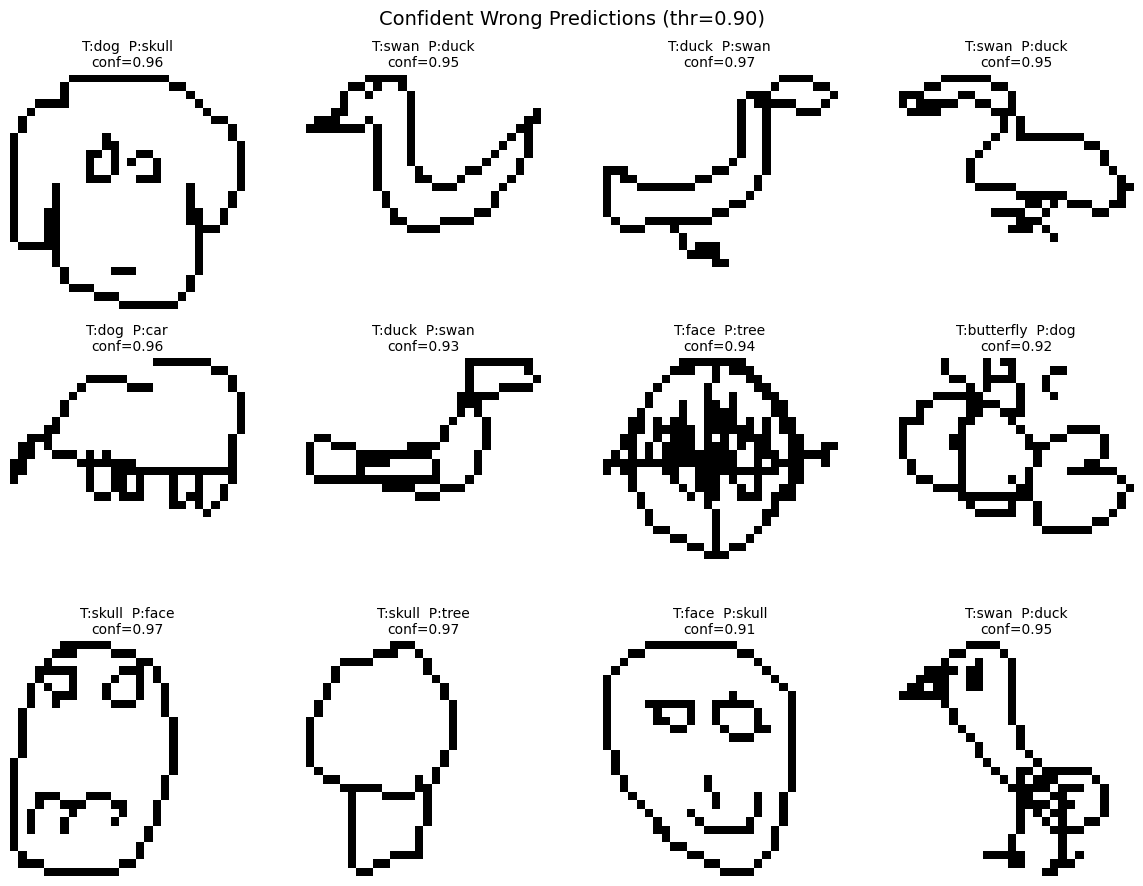

In [21]:
if best_state is not None:
  model_overfit.load_state_dict(best_state)

model_overfit.eval()
model_overfit = model_overfit.to(device)

# Mapping back to class names
idx_to_class = {i: c for c, i in class_to_idx.items()}


all_true = []
all_pred = []
all_conf = []
all_x = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model_overfit(xb)
        probs  = torch.softmax(logits, dim=1)
        conf, pred = torch.max(probs, dim=1)

        all_true.append(yb.cpu())
        all_pred.append(pred.cpu())
        all_conf.append(conf.cpu())
        all_x.append(xb.cpu())

all_true = torch.cat(all_true)
all_pred = torch.cat(all_pred)
all_conf = torch.cat(all_conf)
all_x    = torch.cat(all_x)

# Find confident wrong examples
wrong = (all_pred != all_true)

# Start with 0.90 as requested; if not enough, relax until you get ~10–20
threshold = 0.90
min_needed = 12

def get_confident_wrong_idxs(thr):
    return torch.where(wrong & (all_conf >= thr))[0]

idxs = get_confident_wrong_idxs(threshold)

# Relax threshold if needed (0.90 -> 0.85 -> 0.80 -> 0.75 ...)
while idxs.numel() < min_needed and threshold > 0.50:
    threshold -= 0.05
    idxs = get_confident_wrong_idxs(threshold)

print(f"Using threshold = {threshold:.2f}. Found {idxs.numel()} confident-wrong examples.")

# Take first 12
n_show = min(12, idxs.numel())
idxs_show = idxs[:n_show]

# 3) Plot in a grid (12 images)
nrows, ncols = 3, 4
plt.figure(figsize=(12, 9))

for k, idx in enumerate(idxs_show):
    x_img = all_x[idx].view(28, 28).numpy()   # 784 -> 28x28
    true_i = int(all_true[idx].item())
    pred_i = int(all_pred[idx].item())
    conf_i = float(all_conf[idx].item())

    true_name = idx_to_class[true_i]
    pred_name = idx_to_class[pred_i]

    ax = plt.subplot(nrows, ncols, k+1)
    ax.imshow(x_img, cmap="gray")
    ax.set_title(f"T:{true_name}  P:{pred_name}\nconf={conf_i:.2f}", fontsize=10)
    ax.axis("off")

plt.suptitle(f"Confident Wrong Predictions (thr={threshold:.2f})", fontsize=14)
plt.tight_layout()
plt.show()

The confident wrong predictions show that the model is not making random mistakes. Most errors happen between classes that look visually similar, such as dog vs. cat, swan vs. duck, or apple vs. butterfly. In many cases, the drawings are very simple or missing important details, which makes the classes harder to separate. Because the model is a fully connected network, it mainly looks at the overall shape of the image instead of focusing on small local features like edges or parts of the drawing. This can explain why it sometimes makes very confident but incorrect predictions.

A good improvement would be to use a small Convolutional Neural Network (CNN). A CNN is better at capturing local patterns and spatial structure in images, so it would likely reduce these confusions and improve overall accuracy.

<div class='exercise-r'>

#### 2.3.5 Discussion of Approach
In a few sentences, describe the various approaches you have taken to improve the performance of your regularized model as well as any additional observations you might have regarding your training and Kaggle results.

</div>

To improve my model, I tested several architectural and training modifications.
First, I experimented with different model sizes. A very large network (2048–1024–512) achieved higher training accuracy but clearly overfit the data. A smaller network (1024–512–256) gave a better balance between training and validation accuracy, so I kept this architecture.

I then added L2 regularization (weight decay) and tested different values. A small weight decay (5e-5) helped reduce overfitting without hurting validation performance, so I kept it in the final model.

I also tested dropout (p = 0.1). However, dropout slightly reduced validation accuracy in my experiments and did not improve generalization. Because of that, I decided not to include dropout in the final version.

For data augmentation, I tested three different options based on random translations of the drawings.

- Option A: basic random shifts with small pixel translations.
- Option B: stronger translations with larger shift ranges.
- Option C: lighter and more controlled translations.

All translation methods were implemented using random shifts in the horizontal and vertical directions. The shifted images were placed into a new blank image of the same size (28×28), and the empty areas created by the shift were filled with zeros (black background). This corresponds to zero padding. Any pixels that moved outside the frame were discarded. This approach makes the model more robust to small misalignments while keeping the overall structure of the drawings.

I tuned both Option A and Option B by adjusting the maximum shift range. However, larger translations (stronger shifts) sometimes distorted the drawings too much and slightly reduced validation accuracy. After comparing results, I found that a tuned version of Option C, using small controlled shifts (±2 pixels), provided the best balance. It improved robustness without harming validation performance. Therefore, I selected the tuned Option C as the final augmentation strategy.

I also lowered the learning rate to 5e-4, which made training more stable. In addition, I implemented a learning rate scheduler (ReduceLROnPlateau) to automatically reduce the learning rate when the validation loss stopped improving. This helped the model converge more smoothly and improved final validation performance. I also used early stopping (patience = 5) to automatically keep the best-performing model and prevent unnecessary overfitting.

Overall, the final configuration combined:
- Medium-sized network (1024–512–256)
- L2 regularization (5e-5)
- Tuned Option C data augmentation (small randomized shifts without harmful padding effects)
- Learning rate = 5e-4 with learning rate scheduling
- Early stopping

This combination gave the best validation accuracy among all the approaches I tested.

<div class='exercise-r'>

#### 2.3.6 Generating Submission CSV
Generate your test-set class predictions using your regularized model. Save those predictions to a `.csv` formatted file. Submit that `.csv` file to the CS1090B Kaggle Competition for leaderboard scoring.

**IMPORTANT:** For Kaggle to accept and score your submitted `.csv` file, it MUST contain 2 columns. The first column must be named `"id"` and needs to contain the test observation index numbers corresponding to each of your 30,000 predictions, the second column must be named `"label"` and needs to contain your class predictions (i.e. `cat` or `dog` etc.) for each corresponding test observation index location. A sample submission file has been provided to you.
</div>

In [22]:
# Make sure model is in eval mode

if best_state is not None:
  model_overfit.load_state_dict(best_state)

model_overfit.eval()
model_overfit = model_overfit.to(device)

# Load test data
test_df = pd.read_csv("quickdraw/test.csv")

# Save ids separately
ids = test_df["id"].values

# Drop id column
X_test = test_df.drop(columns=["id"]).values.astype(np.float32) / 255.0

print(X_test.shape)

# Convert test data to tensor
X_test_tensor = torch.FloatTensor(X_test).to(device)

all_preds = []

with torch.no_grad():
    for i in range(0, len(X_test_tensor), batch_size):
        xb = X_test_tensor[i:i+batch_size]
        logits = model_overfit(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

# Convert numeric predictions back to class names
idx_to_class = {i: c for c, i in class_to_idx.items()}
labels = [idx_to_class[p] for p in all_preds]

# Create submission DataFrame
submission = pd.DataFrame({
    "id": ids,
    "label": labels
})

# Save to CSV
submission.to_csv("submission6.csv", index=False)

print("Submission file saved as submission.csv")

(30000, 784)
Submission file saved as submission.csv


<div class='exercise-r'>

#### 2.3.7 Kaggle Leaderboard Name
Specify your Kaggle name that you have used as it appears on the leaderboard. We CANNOT give you credit without this.

</div>

**YOUR KAGGLE LEADERBOARD NAME:**

Corentin Venet

<!-- BEGIN QUESTION -->

<div class='exercise-r'>
    
### 2.4 Wrap-up

* In a few sentences, please describe the aspect(s) of the assignment you found most challenging. This could be conceptual and/or related to coding and implementation.

* How many hours did you spend working on this assignment? Store this as an int or float in `hours_spent_on_hw`. If you worked on the project in a group, report the *average* time spent per person.


</div>

In [23]:
hours_spent_on_hw = int(40)

At the beginning, one of the most challenging parts for me was simply getting used to the interface and the overall workflow. I initially was not running the notebook on GPU, which made training extremely slow and caused me to lose quite a bit of time before realizing the issue. Once that was fixed, things became much smoother.

The second part of the assignment was definitely more challenging conceptually and technically. The longest and most demanding part was testing new ideas to improve the neural network. Trying different architectures, tuning hyperparameters, adjusting regularization, and experimenting with data augmentation required many training runs and careful comparison of validation results. Understanding why some changes improved performance while others hurt it was also an important learning process.

Overall, I would estimate that I spent around 40 hours on this project.

In [24]:
time_end = time.time()
print(f"It took {(time_end - time_start)/60:.2f} minutes for this notebook to run")

It took 36.92 minutes for this notebook to run


**This concludes HW1. Thank you!**